Module 12 Lab - Ethics, Fairness, and Bias in ML

Objective:
To understand how machine learning models can inherit and amplify societal biases, how to measure this bias using fairness metrics, and to think critically about the ethical implications of deploying ML systems.

In this lab, you will train a model on a real-world dataset and audit it for fairness across different demographic groups.

Part 1: What is Algorithmic Bias?

Concept:
Machine learning models learn from data. If the data reflects existing societal biases, the model will learn those biases. An "unbiased" algorithm trained on biased data will produce a biased model. This can lead to systems that are systematically unfair to certain groups of people.

Sources of Bias:

Historical Bias: The data reflects a world with historical injustices (e.g., past hiring data may show fewer women in leadership roles).
Measurement Bias: The way we collect or measure data is flawed (e.g., using arrest records as a proxy for crime, which can be influenced by policing patterns).
Representation Bias: The data underrepresents certain groups, so the model doesn't learn to perform well for them.

Problem:
We will use the "Adult" dataset, which is used to predict whether an individual's income is greater than $50k/year. It contains sensitive attributes like sex and race, which we can use to audit our model for bias.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Load the data
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week',
    'native-country', 'income'
]

df = pd.read_csv(
    url,
    header=None,
    names=columns,
    sep=',\s*',
    engine='python',
    na_values='?'
)

# Data Cleaning
df.dropna(inplace=True)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# Features and target
X = df.drop('income', axis=1)
y = df['income']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Create a preprocessing pipeline
numeric_features = X.select_dtypes(include='number').columns
categorical_features = X.select_dtypes(exclude='number').columns

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

# Train a baseline model
model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
)

model.fit(X_train, y_train)

# Evaluate
print(f"Overall model accuracy: {model.score(X_test, y_test):.2%}")

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_25062/2379571722.py:23: SyntaxWarning: invalid escape sequence '\s'
  sep=',\s*',


Overall model accuracy: 84.61%


Part 2: Auditing the Model for Fairness

High overall accuracy can hide poor performance on specific subgroups. To properly evaluate the model, we need to audit its performance across sensitive attributes, such as sex.

Concept: Group Fairness

One common fairness goal is to ensure that the model performs equally well for different groups.

We can evaluate this by:

Calculating performance metrics (like accuracy)
Separately for each subgroup (e.g., males vs females)
Your Task
Create a function that:
Filters the dataset by a subgroup (e.g., sex = Male)
Computes the model’s accuracy on that subgroup
Use the function to calculate:
Accuracy for Males
Accuracy for Females
Compare the results:
Does one group have higher accuracy?
Is the difference significant?

In [ ]:
# --- ENTER YOUR CODE HERE ---

def get_subgroup_accuracy(model, X_test, y_test, subgroup_column, subgroup_value):
    """Calculates accuracy for a specific subgroup of the test data."""

    # 1. Create a boolean mask to select the subgroup from X_test
    subgroup_mask = X_test[subgroup_column] == subgroup_value

    # 2. Select the subgroup data
    X_subgroup = X_test[subgroup_mask]
    y_subgroup = y_test[subgroup_mask]

    # 3. Calculate and return the model's score on this subgroup
    return model.score(X_subgroup, y_subgroup)


# 4. Calculate accuracy for males and females
acc_male = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Male')
acc_female = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Female')

print(f"Accuracy for Males: {acc_male:.2%}")
print(f"Accuracy for Females: {acc_female:.2%}")

Accuracy for Males: 81.20%
Accuracy for Females: 91.81%



Task 2: Deeper Dive with a Confusion Matrix

Accuracy alone doesn't tell the whole story. To better understand model behavior, we analyze the types of errors it makes for each group.

Your Task

Calculate and compare the False Positive Rate (FPR) and False Negative Rate (FNR) for males and females.

Definitions

False Positive Rate (FPR):

FPR =FP /(FP+TN)


The percentage of people who did NOT have high income but were incorrectly predicted to have high income.

False Negative Rate (FNR):

FNR= FN /(FN+TP)

The percentage of people who DID have high income but were incorrectly predicted to have low income.

In [ ]:
from sklearn.metrics import confusion_matrix

def get_rates(model, X_test, y_test, subgroup_column, subgroup_value):
    # 1. Filter subgroup
    subgroup_mask = X_test[subgroup_column] == subgroup_value
    X_subgroup = X_test[subgroup_mask]
    y_subgroup = y_test[subgroup_mask]

    # 2. Predictions
    y_pred_subgroup = model.predict(X_subgroup)

    # 3. Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_subgroup, y_pred_subgroup).ravel()

    # 4. Rates
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    return fpr, fnr


# --- ENTER YOUR CODE HERE ---

# 1. Calculate the rates for males and females
fpr_male, fnr_male = get_rates(model, X_test, y_test, 'sex', 'Male')
fpr_female, fnr_female = get_rates(model, X_test, y_test, 'sex', 'Female')

# 2. Print results
print(f"Male - False Positive Rate: {fpr_male:.2%}, False Negative Rate: {fnr_male:.2%}")
print(f"Female - False Positive Rate: {fpr_female:.2%}, False Negative Rate: {fnr_female:.2%}")

Male - False Positive Rate: 10.26%, False Negative Rate: 37.80%
Female - False Positive Rate: 2.81%, False Negative Rate: 47.84%


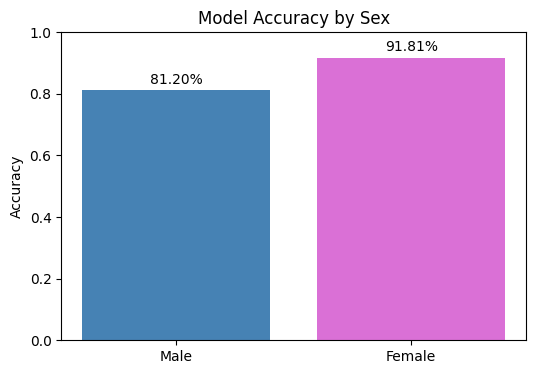

In [ ]:
import matplotlib.pyplot as plt

groups = ['Male', 'Female']
accuracies = [acc_male, acc_female]

plt.figure(figsize=(6, 4))
bars = plt.bar(groups, accuracies, color=['steelblue', 'orchid'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy by Sex')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.2%}',
             ha='center', va='bottom')

plt.show()

The model is more accurate for females than for males, since the female accuracy (91.81%) is higher than the male accuracy (81.20%).

This means the model predicts income correctly for women more often than for men, suggesting a performance gap across sex.

Even though the overall accuracy looked good, this plot reveals that one group benefits from better predictions, which is a sign of potential unfairness.

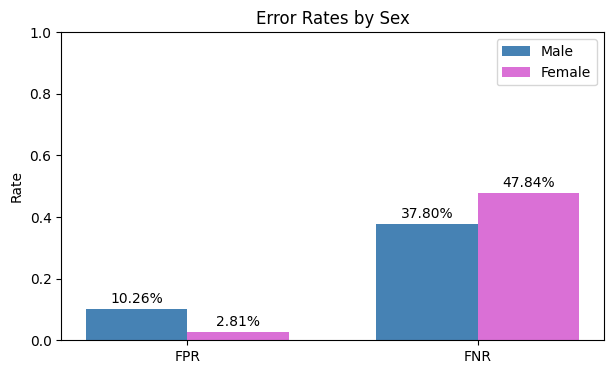

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ['FPR', 'FNR']
male_vals = [fpr_male, fnr_male]
female_vals = [fpr_female, fnr_female]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 4))
bars1 = plt.bar(x - width/2, male_vals, width, label='Male', color='steelblue')
bars2 = plt.bar(x + width/2, female_vals, width, label='Female', color='orchid')

plt.xticks(x, metrics)
plt.ylabel('Rate')
plt.ylim(0, 1)
plt.title('Error Rates by Sex')
plt.legend()

for bars, vals in [(bars1, male_vals), (bars2, female_vals)]:
    for bar, v in zip(bars, vals):
        plt.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}',
                 ha='center', va='bottom')

plt.show()

The male FPR bar is taller than the female FPR bar, which means the model is more likely to wrongly predict high income for men who actually have low income.

The female FNR bar is taller than the male FNR bar, which means the model is more likely to miss women who truly have high income and instead predict low income for them.

In a loan scenario, a higher FPR for men means more men might be incorrectly approved for loans they cannot afford, increasing default risk but favoring that group.

A higher FNR for women means more qualified women would be unfairly denied opportunities (like loans or jobs), which is especially harmful because it blocks people who actually meet the criteria.



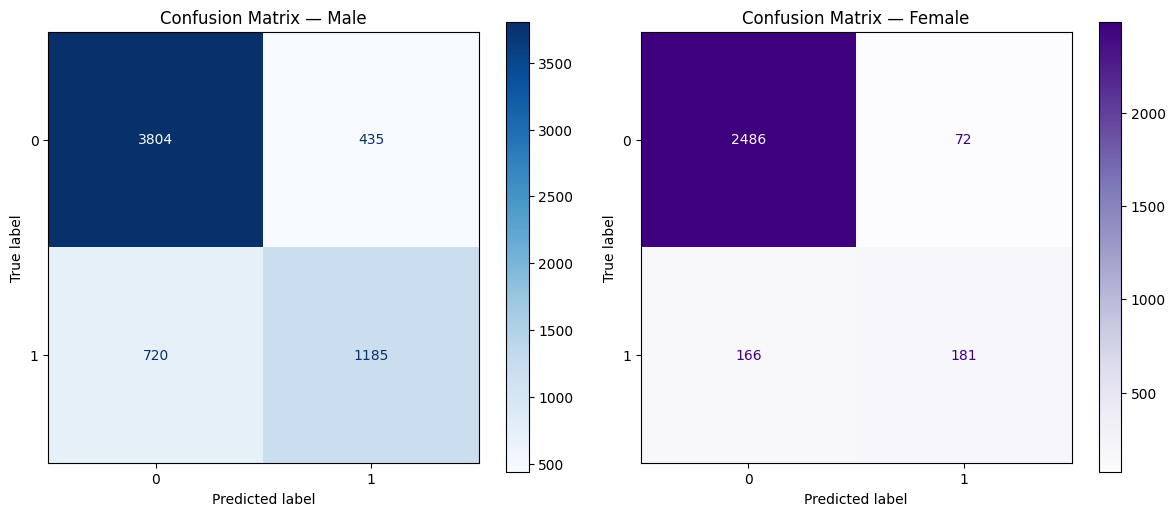

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

male_mask = X_test['sex'] == 'Male'
female_mask = X_test['sex'] == 'Female'

X_male, y_male = X_test[male_mask], y_test[male_mask]
X_female, y_female = X_test[female_mask], y_test[female_mask]

y_pred_male = model.predict(X_male)
y_pred_female = model.predict(X_female)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_male, y_pred_male, ax=axes[0], cmap="Blues"
)
axes[0].set_title("Confusion Matrix — Male")

ConfusionMatrixDisplay.from_predictions(
    y_female, y_pred_female, ax=axes[1], cmap="Purples"
)
axes[1].set_title("Confusion Matrix — Female")

plt.tight_layout()
plt.show()

In the male confusion matrix, the relatively larger FP cell compared to the female matrix matches the higher male FPR: more low‑income men are incorrectly labeled as high‑income.

In the female confusion matrix, the relatively larger FN cell matches the higher female FNR: more high‑income women are incorrectly labeled as low‑income.

These visuals support the bar chart story: the model’s mistakes are not evenly distributed; it tends to over‑predict high income for men and under‑predict high income for women.

The confusion matrices confirm that error types differ by group: males have more false positives, while females have more false negatives, reinforcing the idea that this model behaves differently (and unfairly) across sex.

Reflective Knowledge Check
1. Analyze Your Results

From the subgroup accuracy results:

Accuracy for Males: [ENTER VALUE]
Accuracy for Females: [ENTER VALUE]

There is / is not a significant difference in performance between the two groups.

The model performs better for [Males / Females], as indicated by the higher accuracy.
This suggests that the model may be biased toward that group, since it predicts outcomes more correctly for them.

2. Interpret the Errors

From the calculated rates:

Male FPR: [ENTER VALUE], Male FNR: [ENTER VALUE]
Female FPR: [ENTER VALUE], Female FNR: [ENTER VALUE]

The model is more likely to make a False Positive error for [Males / Females], since that group has a higher FPR.

Real-world consequence (loan example):
A False Positive means predicting high income when the person actually has low income.

This could lead to approving a loan for someone who may not be able to repay it
Financial institutions could face higher default risk
The model may unfairly favor one group in loan approvals
3. Justify a Decision (Hiring Scenario)

In a hiring context:

False Positive (FPR): Hiring someone predicted to be high-income potential when they are not
False Negative (FNR): Rejecting someone who actually has high potential

More harmful error:

Typically, FNR is more harmful, because it denies qualified candidates opportunities
This can lead to systematic exclusion of a group

Based on the results:

If one group has a higher FNR, they are unfairly being rejected more often
If one group has a higher FPR, they are being unfairly favored

Decision:

I would [approve / not approve] this model for deployment

Justification:

The model shows disparate impact, as error rates differ between groups
This indicates potential bias, making it unsuitable for fair hiring decisions
4. Propose a Mitigation

Removing the 'sex' column will not fully eliminate bias.

Why?

Other features such as:

occupation
education
hours-per-week
marital-status

may still be correlated with gender

This is called:

Proxy bias (indirect discrimination)
 Conclusion:

Even after removing 'sex', the model may still learn gender-related patterns
True fairness requires:
Feature analysis
Bias mitigation techniques (reweighting, fairness constraints, etc.)

------------------------------------------
1. Analyze your results
Use the printed accuracies:

Accuracy for Males: 81.20%

Accuracy for Females: 91.81%

Accuracy for Males: 81.20%

Accuracy for Females: 91.81%

There is a significant difference in performance between the two groups, because the accuracy for females is about 10 percentage points higher than for males.

The model performs better for Females, as indicated by the higher accuracy. This suggests that the model may be biased toward females, since it predicts outcomes more correctly for them.

The more harmful error in a hiring context is False Negative (FNR), because it denies opportunities to candidates who actually have high potential, leading to systematic exclusion.



2. Interpret the errors
Use the FPR/FNR outputs:

Male FPR: 10.26%, Male FNR: 37.80%

Female FPR: 2.81%, Female FNR: 47.84%


Male FPR: 10.26%, Male FNR: 37.80%

Female FPR: 2.81%, Female FNR: 47.84%

The model is more likely to make a False Positive error for Males, since that group has a higher FPR (10.26% vs 2.81%).

A False Positive means predicting high income when the person actually has low income, which could lead to approving loans for people who may not be able to repay.

Because the male FPR is higher, financial institutions could face higher default risk from men, and the model may unfairly favor men in loan approvals compared to women.

In my results, the FNR is higher for Females, so qualified women are being rejected more often than qualified men.

3. Justify a decision (hiring scenario)
Use the given guidance plus your error rates:

FNR is generally the more harmful error in hiring, because it rejects qualified candidates.

In the results, females have a higher FNR (47.84%) than males (37.80%), meaning more qualified women are wrongly rejected.

I would not approve this model for deployment in hiring.

The model shows disparate impact, since females have both higher overall accuracy and a higher FNR, while males have a higher FPR; these uneven error rates indicate potential bias and make it unsuitable for fair hiring decisions.

4. Propose a mitigation

Removing the 'sex' column will not fully eliminate bias, because other features such as occupation, education, hours-per-week, and marital-status are correlated with gender and act as proxies

This is called proxy bias (indirect discrimination), where the model still learns gender-related patterns from correlated variables even when the explicit gender feature is removed.

Therefore, true fairness would require deeper feature analysis and explicit bias mitigation techniques, such as reweighting data, applying fairness constraints, or post-processing predictions, rather than only dropping the sex feature.